# 🏆 Customer Churn Prediction – The Ultimate Winning Pipeline

Goal: Build a high-performance machine learning system to accurately predict whether a customer will churn (leave the service) using an ensemble of powerful gradient boosting models.

Models Used:

LightGBM

XGBoost

CatBoost

These models are combined using a stacked ensemble, which often delivers stronger performance than any individual model.

Hardware:
⚡ The pipeline automatically detects and uses GPU acceleration when available to significantly speed up training.

Target Metric:
🎯 LogLoss / ROC-AUC optimization for high-confidence churn probability predictions.

1️⃣ Exploratory Data Analysis (EDA)
Understanding customer behaviour and churn patterns.

2️⃣ Feature Engineering
Creating meaningful features from raw customer data.

3️⃣ Cross-Validation Strategy
Using robust validation to prevent overfitting.

4️⃣ Model Training

LightGBM

XGBoost

CatBoost

5️⃣ Stacked Ensemble Model
Combining predictions to boost performance.

6️⃣ Model Evaluation

ROC-AUC

LogLoss

Feature importance analysis

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import optuna
import gc

print("Libraries imported.")

Libraries imported.


In [2]:
#model = CatBoostClassifier(iterations=5978,learning_rate= 0.002,task_type= 'GPU', devices= '0:1')


In [3]:
#model = XGBClassifier(n_estimators=4445,learning_rate= 0.006,tree_method='hist',device= 'cuda')


# Load Data (Competition Specific)

In [4]:
# Update the paths to match your Kaggle environment
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')
sample_sub = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv')

print(f"Train shape: {train.shape}, Test shape: {test.shape}")

Train shape: (594194, 21), Test shape: (254655, 20)


#  Quick Data Check & Cleaning

In [5]:
train['TotalCharges'] = pd.to_numeric(train['TotalCharges'], errors='coerce')
test['TotalCharges'] = pd.to_numeric(test['TotalCharges'], errors='coerce')
train['TotalCharges'].fillna(0, inplace=True)
test['TotalCharges'].fillna(0, inplace=True)
train['tenure'].fillna(0, inplace=True)
test['tenure'].fillna(0, inplace=True)

print("Missing values after cleaning:")
print(train.isnull().sum().max())
print(test.isnull().sum().max())

Missing values after cleaning:
0
0


In [6]:
train.sample(2)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
316580,316580,Female,0,No,No,14,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Electronic check,89.85,1208.15,No
465087,465087,Male,0,Yes,Yes,59,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.95,1150.85,No


# Exploratory Data Analysis (Optional – skip if short on time)

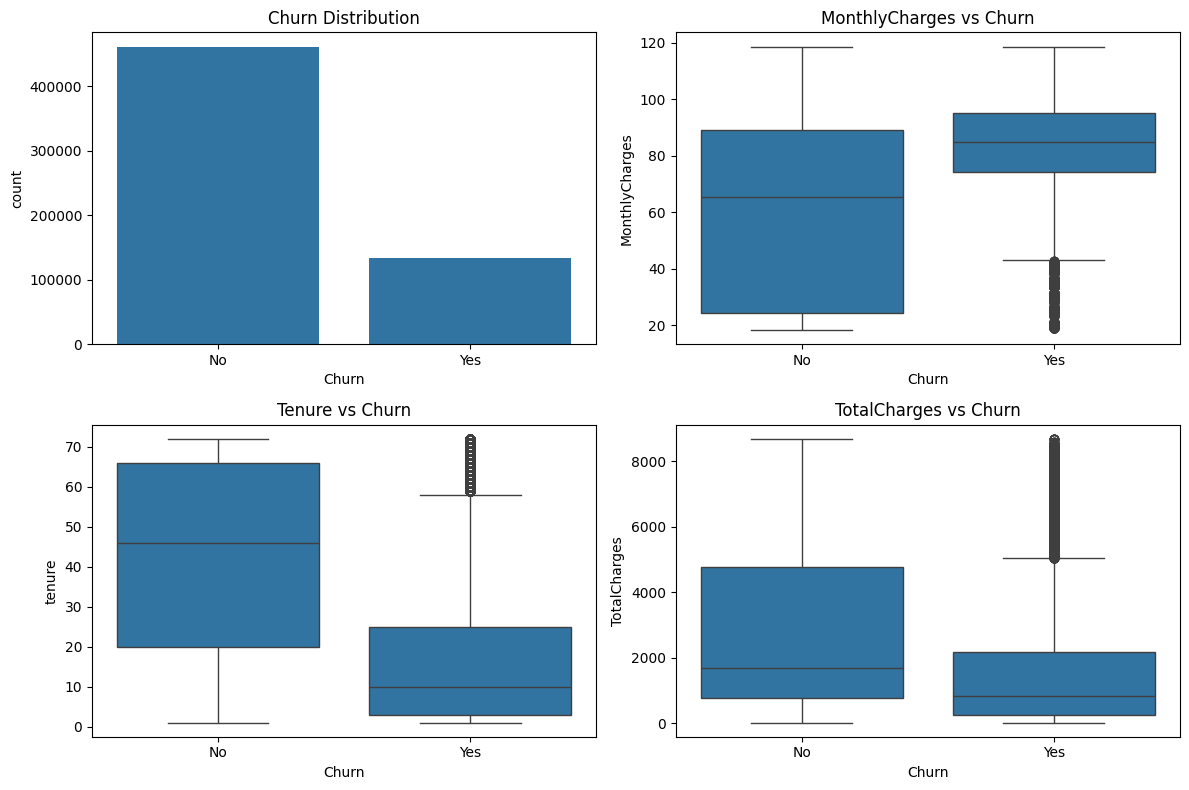

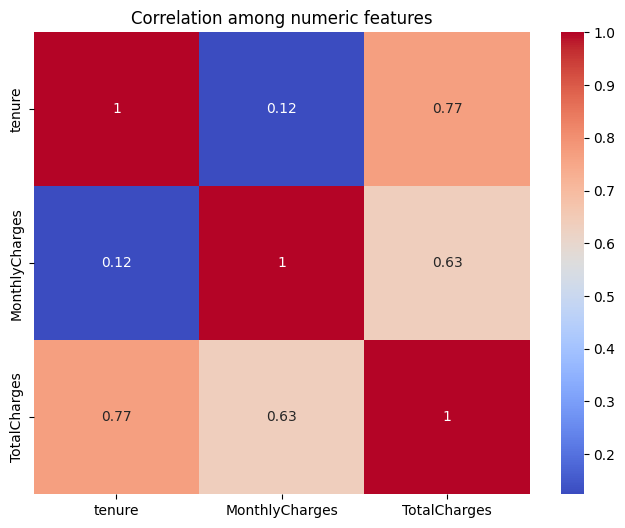

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.countplot(x='Churn', data=train, ax=axes[0,0])
axes[0,0].set_title('Churn Distribution')
sns.boxplot(x='Churn', y='MonthlyCharges', data=train, ax=axes[0,1])
axes[0,1].set_title('MonthlyCharges vs Churn')
sns.boxplot(x='Churn', y='tenure', data=train, ax=axes[1,0])
axes[1,0].set_title('Tenure vs Churn')
sns.boxplot(x='Churn', y='TotalCharges', data=train, ax=axes[1,1])
axes[1,1].set_title('TotalCharges vs Churn')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(train[['tenure','MonthlyCharges','TotalCharges']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation among numeric features')
plt.show()

# Advanced Feature Engineering

In [8]:
train.Churn.value_counts()

Churn
No     460377
Yes    133817
Name: count, dtype: int64

<Axes: xlabel='Churn'>

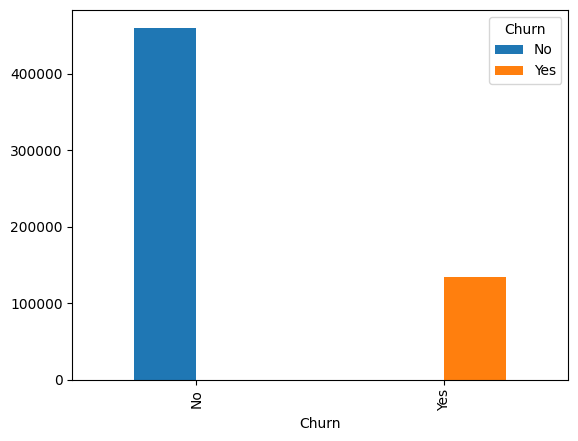

In [9]:
pd.crosstab(train.Churn,train.Churn).plot(kind='bar')

# feature engineering

In [10]:
services = [
'PhoneService','MultipleLines','InternetService',
'OnlineSecurity','OnlineBackup','DeviceProtection',
'TechSupport','StreamingTV','StreamingMovies'
]
for i in services:
    print(f'{i} unique value : {train[i].unique()}')

PhoneService unique value : ['Yes' 'No']
MultipleLines unique value : ['No' 'Yes' 'No phone service']
InternetService unique value : ['DSL' 'Fiber optic' 'No']
OnlineSecurity unique value : ['Yes' 'No' 'No internet service']
OnlineBackup unique value : ['No' 'Yes' 'No internet service']
DeviceProtection unique value : ['Yes' 'No' 'No internet service']
TechSupport unique value : ['Yes' 'No' 'No internet service']
StreamingTV unique value : ['No' 'Yes' 'No internet service']
StreamingMovies unique value : ['No' 'Yes' 'No internet service']


In [11]:
def engineer_features(df):

    eps = 1e-3

    # Spending behavior
    df['avg_spend'] = df['TotalCharges'] / (df['tenure'] + eps)
    df['tenure_x_monthly'] = df['tenure'] * df['MonthlyCharges']

    # Service usage
    services = ['PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection',
        'TechSupport','StreamingTV','StreamingMovies']


    df['num_services'] = df[services].isin(["Yes","DSL","Fiber optic"]).sum(axis=1)

    add_services = ['OnlineSecurity','OnlineBackup','DeviceProtection', 'TechSupport','StreamingTV','StreamingMovies']

    df['num_add_services'] = df[add_services].isin(["Yes"]).sum(axis=1)

    df['per_cost'] = df['MonthlyCharges'] / (df['num_services'] + eps)

    # Contract features
    contract_map = {'Month-to-month':0,'One year':1,'Two year':2}

    df['contract_encoded'] = df['Contract'].map(contract_map).astype(int)

    df['monthly_contract'] = (df['Contract'] == 'Month-to-month').astype(int)

    # Payment risk
    df['is_electronic_check'] = ( df['PaymentMethod'] == 'Electronic check' ).astype(int)

    # Internet risk
    df['has_fiber'] = (df['InternetService'] == 'Fiber optic').astype(int)

    df['fiber_no_support'] = ( (df['has_fiber'] == 1) &(df['TechSupport'] == 'No') ).astype(int)

    # Customer risk
    df['is_new_customer'] = (df['tenure'] <= 6).astype(int)

    return df

In [12]:
# feature engineering apply in test dsat
test = engineer_features(test)
train = engineer_features(train)

# Separate Classes

In [13]:
train=train.drop('id',axis=1)
train['Churn']=train['Churn'].map({'Yes':1, 'No':0})
test=test.drop('id',axis=1)

In [14]:
test.shape

(254655, 30)

In [15]:
train.shape

(594194, 31)

In [16]:
train_yes=train[train['Churn']==1]
train_no=train[train['Churn']==0]

In [17]:
print(train_yes.shape)
print(train_no.shape)

(133817, 31)
(460377, 31)


# Split No Class Into 5 Parts

In [18]:
no_parts = np.array_split(train_no, 5)

# Build Training Datasets

In [19]:
train_sets = []

# manual fold creation

In [20]:

for i in range(5):

    main_part = no_parts[i]

    samples = []

    for j in range(5):
        if j != i:
            samples.append(no_parts[j].sample(20000, random_state=42+i+j))

    extra_samples = pd.concat(samples)

    train_df = pd.concat([main_part, extra_samples, train_yes])
#    take 100% of the rows
    train_df = train_df.sample(frac=1, random_state=42) # shuffling all rows 

    train_sets.append(train_df)

In [21]:
for i in range(5):
    print(train_sets[i].shape)

(305893, 31)
(305893, 31)
(305892, 31)
(305892, 31)
(305892, 31)


In [22]:
test.shape

(254655, 30)

# fold prediction

# encoder for lightgbm for categorical encoding

In [23]:
encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

# categorical feature handeling for catboost

In [24]:
categorical_features=test.select_dtypes(exclude='number').columns.tolist()

In [25]:
categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [26]:
for i in range(len(train_sets)):
    for col in categorical_features:
        train_sets[i][col] = train_sets[i][col].astype('category')

for col in categorical_features:
    test[col] = test[col].astype('category')

In [27]:
import lightgbm as lgb

# manual fold prediction for lightgbm 

In [28]:
test_lgb = np.zeros(len(test))

# lightgbm hyperparameter

In [29]:
SEED=00

In [30]:
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'n_estimators': 1000,
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1
}

In [31]:
for i, df in enumerate(train_sets):

    print('lgb model fold no', i+1, 'training start')

    
    data = df.copy()

    X = data.drop(columns=['Churn'])
    y = data['Churn']

    

    # fit encoder on train
    X_cat = encoder.fit_transform(X[categorical_features])

    X_cat = pd.DataFrame(
        X_cat,
        columns=encoder.get_feature_names_out(categorical_features),
        index=X.index
    )

    # combine numeric + encoded
    x_final = pd.concat(
        [X.drop(columns=categorical_features), X_cat],
        axis=1
    )

    # transform test
    test_cat = encoder.transform(test[categorical_features])

    test_cat = pd.DataFrame(
        test_cat,
        columns=encoder.get_feature_names_out(categorical_features),
        index=test.index
    )

    test_final = pd.concat(
        [test.drop(columns=categorical_features), test_cat],
        axis=1
    )

   
    X_train, X_val, y_train, y_val = train_test_split(x_final, y, test_size=0.2, random_state=42)

    model = lgb.LGBMClassifier(
        n_estimators=800,
        learning_rate=0.5,
        max_depth=7,
        num_leaves=48,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1,
        reg_lambda=5,
        objective='binary'
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(100)]
    )
        
    test_lgb += model.predict_proba(test_final)[:,1] / 5

    print(f" lgb Model {i+1} trained")

lgb model fold no 1 training start
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 107121, number of negative: 137593
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030291 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1432
[LightGBM] [Info] Number of data points in the train set: 244714, number of used features: 41
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.437740 -> initscore=-0.250341
[LightGBM] [Info] Start training from score -0.250341
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[33]	valid_0's auc: 0.914625	valid_0's binary_logloss: 0.364187
 lgb Mod

# xgb classifier

In [32]:
#test_xgb=np.zeros(len(test))

In [33]:
# for i, df in enumerate(train_sets):

#     print('fold no', i+1, 'training start')

    
#     data = df.copy()

#     X = data.drop(columns=['Churn'])
#     y = data['Churn']

    

#     # fit encoder on train
#     X_cat = encoder.fit_transform(X[categorical_features])

#     X_cat = pd.DataFrame(
#         X_cat,
#         columns=encoder.get_feature_names_out(categorical_features),
#         index=X.index
#     )

#     # combine numeric + encoded
#     x_final = pd.concat(
#         [X.drop(columns=categorical_features), X_cat],
#         axis=1
#     )

#     # transform test
#     test_cat = encoder.transform(test[categorical_features])

#     test_cat = pd.DataFrame(test_cat, columns=encoder.get_feature_names_out(categorical_features),index=test.index)

#     test_final = pd.concat([test.drop(columns=categorical_features), test_cat],axis=1)

#     x_train,x_val,y_train,y_val=train_test_split(x_final,y,test_size=0.2,random_state=SEED)

#     model = XGBClassifier(n_estimators=1500)
    
#     model.fit(X_final, y)

#     test_xgb += model.predict_proba(test_final)[:,1] / 5


#     print(f"Model {i+1} trained")

# catboost hyper parametre

In [34]:
cat_params = {
    "iterations": 100,          
    "learning_rate": 0.02,
    "random_seed": SEED,
    "early_stopping_rounds": 3000,
    "verbose": 100,
}

In [35]:
test_cat = np.zeros(len(test))


# catboost fold prediction

In [36]:
for i, df in enumerate(train_sets):
    print( ' catboost fold no :',i+1 ,'trainign start')

    # copy dataset
    data = df.copy()

    # apply feature engineering
    data = engineer_features(data)

    # drop target
    x = data.drop(columns=['Churn'])
    y=data['Churn']


    x_train,x_val,y_train,y_val=train_test_split(x,y,test_size=0.2,random_state=SEED)

    model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.5,
    depth=7,
    l2_leaf_reg=8,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=100
)

    # train model
    model.fit(
        x_train, y_train,
        cat_features=categorical_features,
        eval_set=(x_val, y_val)
    )

    test_cat += model.predict_proba(test)[:,1] / 5

    print(f"catboost trained compelete fold : {i+1} trained")

 catboost fold no : 1 trainign start
0:	test: 0.9002082	best: 0.9002082 (0)	total: 681ms	remaining: 5m 39s
100:	test: 0.9140864	best: 0.9143257 (63)	total: 44.4s	remaining: 2m 55s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9143257397
bestIteration = 63

Shrink model to first 64 iterations.
catboost trained compelete fold : 1 trained
 catboost fold no : 2 trainign start
0:	test: 0.9006658	best: 0.9006658 (0)	total: 596ms	remaining: 4m 57s
100:	test: 0.9151080	best: 0.9152634 (51)	total: 44.6s	remaining: 2m 56s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9152634442
bestIteration = 51

Shrink model to first 52 iterations.
catboost trained compelete fold : 2 trained
 catboost fold no : 3 trainign start
0:	test: 0.8995968	best: 0.8995968 (0)	total: 572ms	remaining: 4m 45s
100:	test: 0.9160392	best: 0.9160727 (96)	total: 44.9s	remaining: 2m 57s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9160727081
bestIteration = 96

# Combined Submission (Equal Weight)

In [37]:
combined = ( test_cat + test_lgb ) / 2

sub_combined = sample_sub.copy()
sub_combined['Churn'] = combined
sub_combined.to_csv('ensemble_equal.csv', index=False)

print("ensemble_equal.csv saved")

ensemble_equal.csv saved


# lgb + XGBoost

In [38]:
# combined = (test_xgb + test_lgb ) / 2

# sub_combined = sample_sub.copy()
# sub_combined['Churn'] = combined
# sub_combined.to_csv('xgb_lgb.csv', index=False)

# print("xgb_lgb.csv saved")

# cat + xgb

In [39]:
# combined = (test_xgb + test_cat ) / 2

# sub_combined = sample_sub.copy()
# sub_combined['Churn'] = combined
# sub_combined.to_csv('cat_xgb.csv', index=False)

# print("cat_xgb.csv saved")

# cat_low+lgb_high

In [40]:
combined = (test_cat*0.3 + test_lgb*0.7 ) / 2

sub_combined = sample_sub.copy()
sub_combined['Churn'] = combined
sub_combined.to_csv('catL_lgbH.csv', index=False)

print("cat_lgb.csv saved")

cat_lgb.csv saved


In [41]:
combined = (test_cat*0.7 + test_lgb*0.3 ) / 2

sub_combined = sample_sub.copy()
sub_combined['Churn'] = combined
sub_combined.to_csv('catH_lgbL.csv', index=False)

print("cat_lgb.csv saved")

cat_lgb.csv saved
